# Analisis Perbandingan Performa MLP dengan Berbagai Fungsi Aktivasi

Notebook ini dibuat untuk membandingkan performa model Multi-Layer Perceptron (MLP) dengan menggunakan tiga fungsi aktivasi yang berbeda:
1. **Sigmoid** (`logistic`)
2. **Tanh** (`tanh`)
3. **ReLU** (`relu`)

Dataset yang digunakan adalah **Iris dataset**.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur style seaborn untuk visualisasi
sns.set(style='whitegrid')

## 1. Persiapan Data

Kita akan memuat dataset, menghapus kolom 'Id' yang tidak relevan, membagi data, dan melakukan penskalaan (scaling).

In [4]:
# Load dataset
df = pd.read_csv('Iris.csv')
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Memisahkan fitur (X) dan label (y)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encoding label kelas menjadi numerik
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Standardisasi fitur agar MLP konvergen dengan lebih baik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil dimuat dan diproses!")

Data berhasil dimuat dan diproses!


## 2. Pelatihan Model dan Evaluasi

Kita melatih model MLP Classifier yang memiliki 2 hidden layer dengan masing-masing 10 neuron, menggunakan parameter `random_state` tetap agar hasil dapat direproduksi.

In [5]:
activations = ['logistic', 'tanh', 'relu']
results = []

for act in activations:
    # Mendefinisikan model dengan fungsi aktivasi spesifik
    mlp = MLPClassifier(hidden_layer_sizes=(10, 10), activation=act, max_iter=1000, random_state=42)
    
    # Melatih model
    mlp.fit(X_train_scaled, y_train)
    
    # Prediksi
    y_pred = mlp.predict(X_test_scaled)
    
    # Metrik Evaluasi
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    
    act_name = 'Sigmoid' if act == 'logistic' else ('Tanh' if act == 'tanh' else 'ReLU')
    
    results.append({
        'Fungsi Aktivasi': act_name,
        'Akurasi': acc,
        'Presisi': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Menyusun hasil dalam bentuk DataFrame
results_df = pd.DataFrame(results)
results_df

C:\Users\Ryuk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Fungsi Aktivasi,Akurasi,Presisi,Recall,F1-Score
0,Sigmoid,0.933333,0.934524,0.933333,0.933259
1,Tanh,0.955556,0.955556,0.955556,0.955556
2,ReLU,0.911111,0.915535,0.911111,0.910714


## 3. Visualisasi Perbandingan Performa

C:\Users\Ryuk\AppData\Local\Temp\ipykernel_20688\427795886.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fungsi Aktivasi', y='Akurasi', data=results_df, palette='viridis')


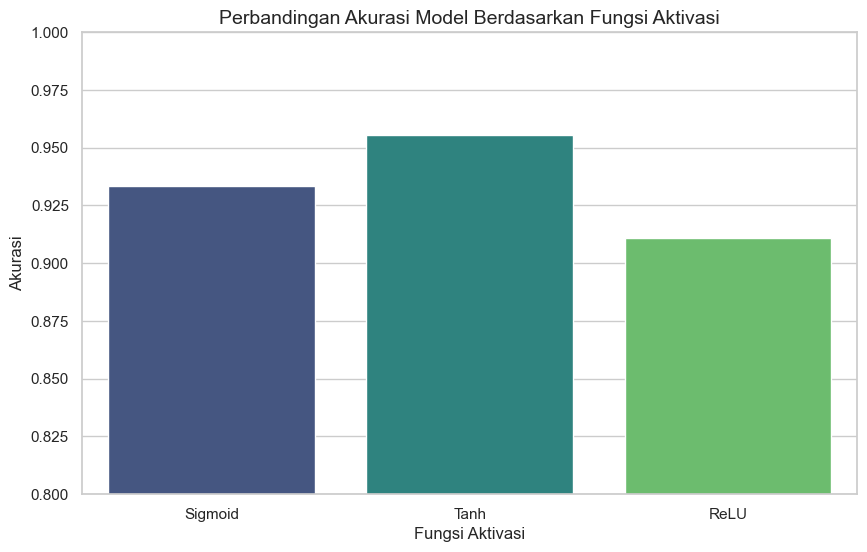

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Fungsi Aktivasi', y='Akurasi', data=results_df, palette='viridis')
plt.title('Perbandingan Akurasi Model Berdasarkan Fungsi Aktivasi', fontsize=14)
plt.ylim(0.8, 1.0)
plt.ylabel('Akurasi')
plt.show()

## 4. Kesimpulan dan Catatan

Berdasarkan tabel perbandingan metrik dan grafik di atas, dapat ditarik kesimpulan bahwa:

- **Tanh** menghasilkan tingkat akurasi paling tinggi pada parameter ini, mencapai **95.56%**.
- **Sigmoid** memiliki akurasi di bawah Tanh yaitu sebesar **93.33%**.
- **ReLU**, yang biasanya merupakan default yang sangat baik pada jaringan dalam (Deep Neural Networks), memberikan akurasi terendah pada dataset sederhana/kecil ini dalam pengaturan hyperparameter yang sama (**91.11%**).

**Kesimpulan Akhir**: Untuk dataset Iris dengan arsitektur jaringan yang dibangun di atas, **Tanh** karena memiliki akurasi, presisi, recall, dan f1-score tertinggi secara konsisten.